In [1]:
pip install torchvision torch

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
  def __init__(self):
    super(Net, self).__init__()

    self.conv1 = nn.Conv1d(1, 32, 5)
    self.conv2 = nn.Conv1d(32, 64, 5)
    self.conv3 = nn.Conv1d(64, 64, 5)

    self.conv1_bnorm = nn.BatchNorm1d(32)
    self.conv2_bnorm = nn.BatchNorm1d(64)
    self.conv3_bnorm = nn.BatchNorm1d(64)

    self.dropout = nn.Dropout(0.3)

    self.adaptivepool = nn.AdaptiveAvgPool1d(1)

    self.fc = nn.Linear(64, 1)

  def forward(self, x):
    x1 = self.conv1(x)
    x1 = self.conv1_bnorm(x1)
    x1 = F.relu(x1)
    x1 = F.max_pool1d(x1, 2)

    x2 = self.conv2(x1)
    x2 = self.conv2_bnorm(x2)
    x2 = F.relu(x2)
    x2 = F.max_pool1d(x2, 2)

    x3 = self.conv3(x2)
    x3 = self.conv3_bnorm(x3)
    x3 = F.relu(x3)
    x3 = F.max_pool1d(x3, 2)

    x3 = self.adaptivepool(x3)
    x3 = x3.squeeze(-1)
    x3 = self.dropout(x3)
    x3 = self.fc(x3)

    output = x3

    return output

In [3]:
pip install h5py

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from torch.utils.data import Dataset
import h5py

with h5py.File('/Users/alexanderwuckert/Desktop/task2/data/Subject01.mat', 'r') as f:
    labels = f['Subject01']['Walking']['Metabolics_System']['Labels']
    print(type(labels))
    print(labels.shape)


with h5py.File('/Users/alexanderwuckert/Desktop/task2/data/Subject01.mat', 'r') as f:
    labels = f['Subject01']['Walking']['Metabolics_System']['Labels']
    for i, label in enumerate(labels):
        # dereference the HDF5 reference
        ref = label[0]
        name = ''.join(chr(c) for c in f[ref][:].flatten())
        print(i, name)


<class 'h5py._hl.dataset.Dataset'>
(9, 1)
0 Time (s)
1 Activity Code
2 VO2 (mL/s)
3 VCO2 (mL/s)
4 RER
5 Breath Frequency (1/min)
6 Minute Ventiltation (L/min)
7 Oxygen Saturation, SpO2 (%)
8 Heart Rate (1/min)


In [5]:
import numpy as np

def calculate_ee(time, vo2, vco2, body_mass):
  mask = time >= 180
  vo2_last3min = vo2[mask]
  vco2_last3min = vco2[mask]
  EE_W = 16.58 * vo2_last3min + 4.51 * vco2_last3min
  EE_W_KG = EE_W / body_mass

  return EE_W_KG.mean()

with h5py.File('/Users/alexanderwuckert/Desktop/task2/data/Subject01.mat', 'r') as f:
    time = f['Subject01']['Walking']['Metabolics_System']['Data'][0]
    vo2 = f['Subject01']['Walking']['Metabolics_System']['Data'][2]
    vco2 = f['Subject01']['Walking']['Metabolics_System']['Data'][3]

calculate_ee(time, vo2, vco2, 63.49)


np.float64(3.0296991763718806)

In [6]:

subjects = ['Subject01', 'Subject02', 'Subject03', 'Subject04', 'Subject05', 'Subject06', 'Subject07', 'Subject08', 'Subject09', 'Subject10']
activities = ['Walking', 'Running', 'Cycling', 'Backwards', 'Incline']
body_masses = [63.49, 63.49, 71.2, 68.03, 68.03, 68.03, 95.24, 65.76, 68.93, 58.05]

body_masses = {
    'Subject01': 63.49,
    'Subject02': 63.49,
    'Subject03': 71.2,
    'Subject04': 68.03,
    'Subject05': 68.03,
    'Subject06': 68.03,
    'Subject07': 95.24,
    'Subject08': 65.76,
    'Subject09': 68.93,
    'Subject10': 58.05
}

labels = {}


for subject in subjects:
  for activity in activities:
    try:
      with h5py.File(f'/Users/alexanderwuckert/Desktop/task2/data/{subject}.mat', 'r') as f:
        data = f[subject][activity]['Metabolics_System']['Data'][:]
        time = data[0]
        activity_codes = data[1]
        vo2 = data[2]
        vco2 = data[3]
        for code in np.unique(activity_codes):
          mask = (activity_codes == code) & (time >= 180)
          labels[(subject, activity, code)] = calculate_ee(time[mask], vo2[mask], vco2[mask], body_masses[subject])
    except Exception as e:
          print(f"Skipping {subject} {activity}: {e}")
          continue


In [7]:
import pickle
with open('/Users/alexanderwuckert/Desktop/task2/labels.pkl', 'wb') as f:
    pickle.dump(labels, f)
print("Labels saved")

Labels saved


In [8]:
import os

_data_cache = {}
_cache_file = '/Users/alexanderwuckert/Desktop/task2/hdf5_cache.pkl'

def load_cache():
    global _data_cache
    if os.path.exists(_cache_file):
        with open(_cache_file, 'rb') as f:
            _data_cache = pickle.load(f)
        print(f"Loaded cache: {len(_data_cache)} entries")
    else:
        print("No cache file yet")

def save_cache():
    with open(_cache_file, 'wb') as f:
        pickle.dump(_data_cache, f)

def get_data(subject, activity, group):
    """returns the full data array for (subject, activity, group), 
    reading from HDF5 only the first time"""
    key = (subject, activity, group)
    if key not in _data_cache:
        with h5py.File(f'/Users/alexanderwuckert/Desktop/task2/data/{subject}.mat', 'r') as f:
            _data_cache[key] = f[subject][activity][group]['Data'][:]
    return _data_cache[key]

load_cache()

Loaded cache: 100 entries


In [9]:
class EEDataset(Dataset):
    def __init__(self, subjects, labels, sensor_group='Metabolics_System', 
                 signal_row=8, window_size=128):
        self.windows = []
        self.targets = []
        
        for subject in subjects:
            for activity in activities:
                try:
                        data = get_data(subject, activity, sensor_group)
                        activity_codes = data[1]
                        if isinstance(signal_row, list):
                            signal = np.sqrt(np.sum(data[signal_row]**2, axis=0))
                        else:
                            signal = data[signal_row]
                        
                        for code in np.unique(activity_codes):
                            label = labels.get((subject, activity, code), None)
                            if label is None:
                                continue
                            mask = activity_codes == code
                            signal_condition = signal[mask]
                            
                            for i in range(0, len(signal_condition) - window_size, window_size):
                                window = signal_condition[i:i+window_size]
                                if np.isnan(window).any():
                                    continue
                                self.windows.append(torch.tensor(window, dtype=torch.float32).unsqueeze(0))
                                self.targets.append(torch.tensor(label, dtype=torch.float32))
                except:
                    continue

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        return self.windows[idx], self.targets[idx]

In [10]:
test_dataset = EEDataset(['Subject01'], labels)
print(f"Windows: {len(test_dataset)}")
print(f"Sample shape: {test_dataset[0][0].shape}")
print(f"Sample label: {test_dataset[0][1]}")

Windows: 9
Sample shape: torch.Size([1, 128])
Sample label: 8.44246768951416


In [11]:
from torch.utils.data import DataLoader

train_subjects = ['Subject01', 'Subject02', 'Subject03', 'Subject04', 'Subject05', 
                  'Subject06', 'Subject07', 'Subject08', 'Subject09']
test_subject = ['Subject10']

train_dataset = EEDataset(train_subjects, labels)
test_dataset = EEDataset(test_subject, labels)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print(f"Train windows: {len(train_dataset)}")
print(f"Test windows: {len(test_dataset)}")

Train windows: 97
Test windows: 22


In [12]:
import torch.optim as optim

model = Net()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for windows, targets in train_loader:
        optimizer.zero_grad()
        predictions = model(windows)
        loss = criterion(predictions.squeeze(1), targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {train_loss/len(train_loader):.4f}")

Epoch 0, Loss: 54.6089
Epoch 10, Loss: 19.2957
Epoch 20, Loss: 4.8153
Epoch 30, Loss: 5.8512
Epoch 40, Loss: 4.1793


In [13]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [14]:
from sklearn.metrics import r2_score
import numpy as np

all_subjects = ['Subject01', 'Subject02', 'Subject03', 'Subject04', 'Subject05',
                'Subject06', 'Subject07', 'Subject08', 'Subject09', 'Subject10']

results = {}

for test_subject in all_subjects:
    train_subjects = [s for s in all_subjects if s != test_subject]
    
    train_dataset = EEDataset(train_subjects, labels)
    test_dataset = EEDataset([test_subject], labels)
    
    if len(test_dataset) == 0:
        print(f"Skipping {test_subject} - no data")
        continue
    
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)
    
    model = Net()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    
    for epoch in range(20):
        model.train()
        for windows, targets in train_loader:
            optimizer.zero_grad()
            predictions = model(windows)
            loss = criterion(predictions.squeeze(1), targets)
            loss.backward()
            optimizer.step()
    
    model.eval()
    preds, actuals = [], []
    with torch.no_grad():
        for windows, targets in test_loader:
            predictions = model(windows)
            preds.extend(predictions.squeeze(1).numpy())
            actuals.extend(targets.numpy())
    
    preds = np.array(preds)
    actuals = np.array(actuals)
    rmse = np.sqrt(np.mean((preds - actuals)**2))
    mae = np.mean(np.abs(preds - actuals))
    r2 = r2_score(actuals, preds)
    
    results[test_subject] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    print(f"{test_subject}: RMSE={rmse:.3f}, MAE={mae:.3f}, R²={r2:.3f}")

print(f"\nMean RMSE: {np.mean([r['RMSE'] for r in results.values()]):.3f}")
print(f"Mean MAE: {np.mean([r['MAE'] for r in results.values()]):.3f}")
print(f"Mean R²: {np.mean([r['R2'] for r in results.values()]):.3f}")

Subject01: RMSE=5.255, MAE=4.780, R²=-2.846
Subject02: RMSE=7.352, MAE=7.349, R²=-20.655
Subject03: RMSE=1.584, MAE=1.195, R²=0.745
Subject04: RMSE=1.570, MAE=1.387, R²=0.827
Subject05: RMSE=2.950, MAE=2.339, R²=0.407
Subject06: RMSE=3.476, MAE=3.190, R²=-0.378
Subject07: RMSE=2.729, MAE=1.914, R²=0.114
Subject08: RMSE=1.161, MAE=0.962, R²=0.824
Subject09: RMSE=4.369, MAE=3.672, R²=-0.322
Subject10: RMSE=1.201, MAE=1.022, R²=0.749

Mean RMSE: 3.165
Mean MAE: 2.781
Mean R²: -2.054


In [15]:
with h5py.File('/Users/alexanderwuckert/Desktop/task2/data/Subject01.mat', 'r') as f:
    for group in ['APDM_Accel', 'Empatica_Accel', 'Empatica_Physio', 'EMG']:
        labels_data = f['Subject01']['Walking'][group]['Labels']
        print(f"\n{group} shape: {labels_data.shape}")
        for i, label in enumerate(labels_data):
            ref = label[0]
            name = ''.join(chr(c) for c in f[ref][:].flatten())
            print(f"  {i}: {name}")


APDM_Accel shape: (56, 3)
  0: Time (s)
  1: Activity Code
  2: Waist
  3: Waist
  4: Waist
  5: Waist
  6: Waist
  7: Waist
  8: Waist
  9: Waist
  10: Waist
  11: Chest
  12: Chest
  13: Chest
  14: Chest
  15: Chest
  16: Chest
  17: Chest
  18: Chest
  19: Chest
  20: Left Ankle
  21: Left Ankle
  22: Left Ankle
  23: Left Ankle
  24: Left Ankle
  25: Left Ankle
  26: Left Ankle
  27: Left Ankle
  28: Left Ankle
  29: Right Ankle
  30: Right Ankle
  31: Right Ankle
  32: Right Ankle
  33: Right Ankle
  34: Right Ankle
  35: Right Ankle
  36: Right Ankle
  37: Right Ankle
  38: Left Foot
  39: Left Foot
  40: Left Foot
  41: Left Foot
  42: Left Foot
  43: Left Foot
  44: Left Foot
  45: Left Foot
  46: Left Foot
  47: Right Foot
  48: Right Foot
  49: Right Foot
  50: Right Foot
  51: Right Foot
  52: Right Foot
  53: Right Foot
  54: Right Foot
  55: Right Foot

Empatica_Accel shape: (8, 3)
  0: Time (s)
  1: Activity Code
  2: Left Wrist
  3: Left Wrist
  4: Left Wrist
  5: Righ

In [16]:
with h5py.File('/Users/alexanderwuckert/Desktop/task2/data/Subject01.mat', 'r') as f:
    print(list(f['Subject01']['Walking']['APDM_Accel'].keys()))
    data = f['Subject01']['Walking']['APDM_Accel']['Data'][:]
    print(data.shape)

['Data', 'Labels', 'SamplingRate']
(56, 230772)


In [17]:
with h5py.File('/Users/alexanderwuckert/Desktop/task2/data/Subject01.mat', 'r') as f:
    for group in ['Empatica_Accel', 'Empatica_Physio', 'EMG']:
        data = f['Subject01']['Walking'][group]['Data'][:]
        labels_data = f['Subject01']['Walking'][group]['Labels']
        print(f"\n{group} — shape: {data.shape}")
        for i, label in enumerate(labels_data):
            ref = label[0]
            name = ''.join(chr(c) for c in f[ref][:].flatten())
            print(f"  {i}: {name}")


Empatica_Accel — shape: (8, 57692)
  0: Time (s)
  1: Activity Code
  2: Left Wrist
  3: Left Wrist
  4: Left Wrist
  5: Right Wrist
  6: Right Wrist
  7: Right Wrist

Empatica_Physio — shape: (6, 7211)
  0: Time (s)
  1: Activity Code
  2: Left Wrist
  3: Left Wrist
  4: Right Wrist
  5: Right Wrist

EMG — shape: (18, 1802658)
  0: Time (s)
  1: Activity Code
  2: Left Leg
  3: Left Leg
  4: Left Leg
  5: Left Leg
  6: Left Leg
  7: Left Leg
  8: Left Leg
  9: Left Leg
  10: Right Leg
  11: Right Leg
  12: Right Leg
  13: Right Leg
  14: Right Leg
  15: Right Leg
  16: Right Leg
  17: Right Leg


In [18]:
signal_configs = {
    'HeartRate':         ('Metabolics_System', 8),
    'BreathFrequency':   ('Metabolics_System', 5),
    'MinuteVentilation': ('Metabolics_System', 6),
    'SpO2':              ('Metabolics_System', 7),
    'WaistAccel':        ('APDM_Accel', [2,3,4]),
    'ChestAccel':        ('APDM_Accel', [11,12,13]),
    'LeftAnkleAccel':    ('APDM_Accel', [20,21,22]),
    'RightAnkleAccel':   ('APDM_Accel', [29,30,31]),
    'LeftWristAccel':    ('Empatica_Accel', [2,3,4]),    # verify indices
    'RightWristAccel':   ('Empatica_Accel', [5,6,7]),    # verify indices
    'LeftEDA':           ('Empatica_Physio', 2),          # verify indices
    'RightEDA':          ('Empatica_Physio', 3),          # verify indices
    'LeftTemp':          ('Empatica_Physio', 4),          # verify indices
    'RightTemp':         ('Empatica_Physio', 5),          # verify indices
    'LeftEMG':           ('EMG', None),                   # fill after Cell 1
    'RightEMG':          ('EMG', None),                   # fill after Cell 1
}

In [ ]:
import gc  

def run_loso(sensor_group, signal_row, signal_name=""):
    all_subjects = ['Subject01', 'Subject02', 'Subject03', 'Subject04', 'Subject05',
                    'Subject06', 'Subject07', 'Subject08', 'Subject09', 'Subject10']
    fold_results = []
    
    for test_subject in all_subjects:
        train_subjects = [s for s in all_subjects if s != test_subject]
        
        train_dataset = EEDataset(train_subjects, labels, sensor_group, signal_row)
        test_dataset = EEDataset([test_subject], labels, sensor_group, signal_row)
        
        if len(test_dataset) < 5:
            continue
        
        train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)
        
        model = Net()
        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
        
        for epoch in range(20):
            model.train()
            for windows, targets in train_loader:
                optimizer.zero_grad()
                predictions = model(windows)
                loss = criterion(predictions.squeeze(1), targets)
                loss.backward()
                optimizer.step()
        
        model.eval()
        preds, actuals = [], []
        with torch.no_grad():
            for windows, targets in test_loader:
                predictions = model(windows)
                preds.extend(predictions.squeeze(1).numpy())
                actuals.extend(targets.numpy())
        
        preds = np.array(preds)
        actuals = np.array(actuals)

        
        valid = ~(np.isnan(preds) | np.isnan(actuals))
        preds = preds[valid]
        actuals = actuals[valid]

        if len(preds) < 2:
            continue

        rmse = np.sqrt(np.mean((preds - actuals)**2))
        mae = np.mean(np.abs(preds - actuals))
        r2 = r2_score(actuals, preds)
        fold_results.append({'RMSE': rmse, 'MAE': mae, 'R2': r2})

        del train_dataset, test_dataset, train_loader, test_loader, model, optimizer
        gc.collect()
    
    save_cache()  

    if fold_results:
        mean_rmse = np.mean([r['RMSE'] for r in fold_results])
        mean_mae = np.mean([r['MAE'] for r in fold_results])
        mean_r2 = np.mean([r['R2'] for r in fold_results])
        print(f"{signal_name}: RMSE={mean_rmse:.3f}, MAE={mean_mae:.3f}, R²={mean_r2:.3f}")
        return mean_rmse, mean_mae, mean_r2
    return None, None, None

In [20]:
phase1_results = {}

for signal_name, (group, row) in signal_configs.items():
    if row is None:
        continue
    rmse, mae, r2 = run_loso(group, row, signal_name)
    if rmse is not None:
        phase1_results[signal_name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
        # save after each signal
        with open('/Users/alexanderwuckert/Desktop/task2/phase1_results.pkl', 'wb') as f:
            pickle.dump(phase1_results, f)
        print(f"Saved {signal_name}")

HeartRate: RMSE=2.645, MAE=2.161, R²=0.154
Saved HeartRate
BreathFrequency: RMSE=2.393, MAE=1.992, R²=0.376
Saved BreathFrequency
MinuteVentilation: RMSE=1.536, MAE=1.252, R²=0.680
Saved MinuteVentilation
SpO2: RMSE=3.472, MAE=2.829, R²=-0.267
Saved SpO2


KeyboardInterrupt: 

In [ ]:
import pickle
with open('/Users/alexanderwuckert/Desktop/task2/phase1_results.pkl', 'rb') as f:
    r = pickle.load(f)
print(list(r.keys()))

['HeartRate', 'BreathFrequency', 'MinuteVentilation', 'SpO2']


In [ ]:
import os
print(f"Cache entries: {len(_data_cache)}")
print(f"Cache file size: {os.path.getsize(_cache_file) / 1e6:.1f} MB")

Cache entries: 100
Cache file size: 2.4 MB


In [ ]:
print(list(_data_cache.keys()))

[('Subject01', 'Walking', 'Metabolics_System'), ('Subject01', 'Running', 'Metabolics_System'), ('Subject01', 'Cycling', 'Metabolics_System'), ('Subject01', 'Backwards', 'Metabolics_System'), ('Subject01', 'Incline', 'Metabolics_System'), ('Subject02', 'Walking', 'Metabolics_System'), ('Subject02', 'Running', 'Metabolics_System'), ('Subject02', 'Cycling', 'Metabolics_System'), ('Subject02', 'Backwards', 'Metabolics_System'), ('Subject02', 'Incline', 'Metabolics_System'), ('Subject03', 'Walking', 'Metabolics_System'), ('Subject03', 'Running', 'Metabolics_System'), ('Subject03', 'Cycling', 'Metabolics_System'), ('Subject03', 'Backwards', 'Metabolics_System'), ('Subject03', 'Incline', 'Metabolics_System'), ('Subject04', 'Walking', 'Metabolics_System'), ('Subject04', 'Running', 'Metabolics_System'), ('Subject04', 'Cycling', 'Metabolics_System'), ('Subject04', 'Backwards', 'Metabolics_System'), ('Subject04', 'Incline', 'Metabolics_System'), ('Subject05', 'Walking', 'Metabolics_System'), ('Su

In [ ]:
print(phase1_results)

NameError: name 'phase1_results' is not defined

In [21]:
# Load saved results first
import datetime


with open('/Users/alexanderwuckert/Desktop/task2/phase1_results.pkl', 'rb') as f:
    phase1_results = pickle.load(f)

print(f"Already have: {list(phase1_results.keys())}")

# Run only remaining signals
for signal_name, (group, row) in signal_configs.items():
    if row is None:
        continue
    if signal_name in phase1_results:
        print(f"Skipping {signal_name} — already done")
        continue
    print(f"Starting {signal_name} at {datetime.datetime.now().strftime('%H:%M:%S')}")
    rmse, mae, r2 = run_loso(group, row, signal_name)
    if rmse is not None:
        phase1_results[signal_name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
        with open('/Users/alexanderwuckert/Desktop/task2/phase1_results.pkl', 'wb') as f:
            pickle.dump(phase1_results, f)
        print(f"Done {signal_name} at {datetime.datetime.now().strftime('%H:%M:%S')}")

Already have: ['HeartRate', 'BreathFrequency', 'MinuteVentilation', 'SpO2']
Skipping HeartRate — already done
Skipping BreathFrequency — already done
Skipping MinuteVentilation — already done
Skipping SpO2 — already done
Starting WaistAccel at 01:14:38
WaistAccel: RMSE=1.721, MAE=1.213, R²=0.647
Done WaistAccel at 02:12:42
Starting ChestAccel at 02:12:42
ChestAccel: RMSE=1.698, MAE=1.185, R²=0.658
Done ChestAccel at 03:09:49
Starting LeftAnkleAccel at 03:09:49
LeftAnkleAccel: RMSE=1.367, MAE=0.978, R²=0.778
Done LeftAnkleAccel at 04:06:55
Starting RightAnkleAccel at 04:06:55
RightAnkleAccel: RMSE=1.323, MAE=0.934, R²=0.793
Done RightAnkleAccel at 05:03:59
Starting LeftWristAccel at 05:03:59
LeftWristAccel: RMSE=1.654, MAE=1.206, R²=0.665
Done LeftWristAccel at 05:18:12
Starting RightWristAccel at 05:18:12
RightWristAccel: RMSE=1.965, MAE=1.526, R²=0.440
Done RightWristAccel at 05:31:47
Starting LeftEDA at 05:31:47
LeftEDA: RMSE=2.734, MAE=2.119, R²=0.105
Done LeftEDA at 05:33:36
Starti

In [22]:
print("\n=== PHASE 1 COMPLETE ===")
sorted_results = sorted(phase1_results.items(), key=lambda x: x[1]['RMSE'])
for signal, metrics in sorted_results:
    print(f"{signal}: RMSE={metrics['RMSE']:.3f}, MAE={metrics['MAE']:.3f}, R²={metrics['R2']:.3f}")


=== PHASE 1 COMPLETE ===
RightAnkleAccel: RMSE=1.323, MAE=0.934, R²=0.793
LeftAnkleAccel: RMSE=1.367, MAE=0.978, R²=0.778
MinuteVentilation: RMSE=1.536, MAE=1.252, R²=0.680
LeftWristAccel: RMSE=1.654, MAE=1.206, R²=0.665
ChestAccel: RMSE=1.698, MAE=1.185, R²=0.658
WaistAccel: RMSE=1.721, MAE=1.213, R²=0.647
RightWristAccel: RMSE=1.965, MAE=1.526, R²=0.440
BreathFrequency: RMSE=2.393, MAE=1.992, R²=0.376
HeartRate: RMSE=2.645, MAE=2.161, R²=0.154
LeftTemp: RMSE=2.731, MAE=2.052, R²=0.048
LeftEDA: RMSE=2.734, MAE=2.119, R²=0.105
RightTemp: RMSE=2.945, MAE=2.362, R²=-0.078
RightEDA: RMSE=2.996, MAE=2.404, R²=-0.052
SpO2: RMSE=3.472, MAE=2.829, R²=-0.267


In [23]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [24]:
import matplotlib.pyplot as plt

def plot_signal_ranking(phase1_results):
    sorted_results = sorted(phase1_results.items(), key=lambda x: x[1]['RMSE'])
    signals = [r[0] for r in sorted_results]
    rmses = [r[1]['RMSE'] for r in sorted_results]
    r2s = [r[1]['R2'] for r in sorted_results]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    ax1.barh(signals, rmses, color='steelblue')
    ax1.set_xlabel('RMSE (W/kg)')
    ax1.set_title('Phase 1: Signal Ranking by RMSE (lower is better)')
    
    colors = ['green' if r > 0 else 'red' for r in r2s]
    ax2.barh(signals, r2s, color=colors)
    ax2.set_xlabel('R²')
    ax2.set_title('Phase 1: Signal Ranking by R²')
    ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    
    plt.tight_layout()
    plt.savefig('/Users/alexanderwuckert/Desktop/task2/phase1_signal_ranking.png', dpi=150)
    plt.show()
    print("Saved.")

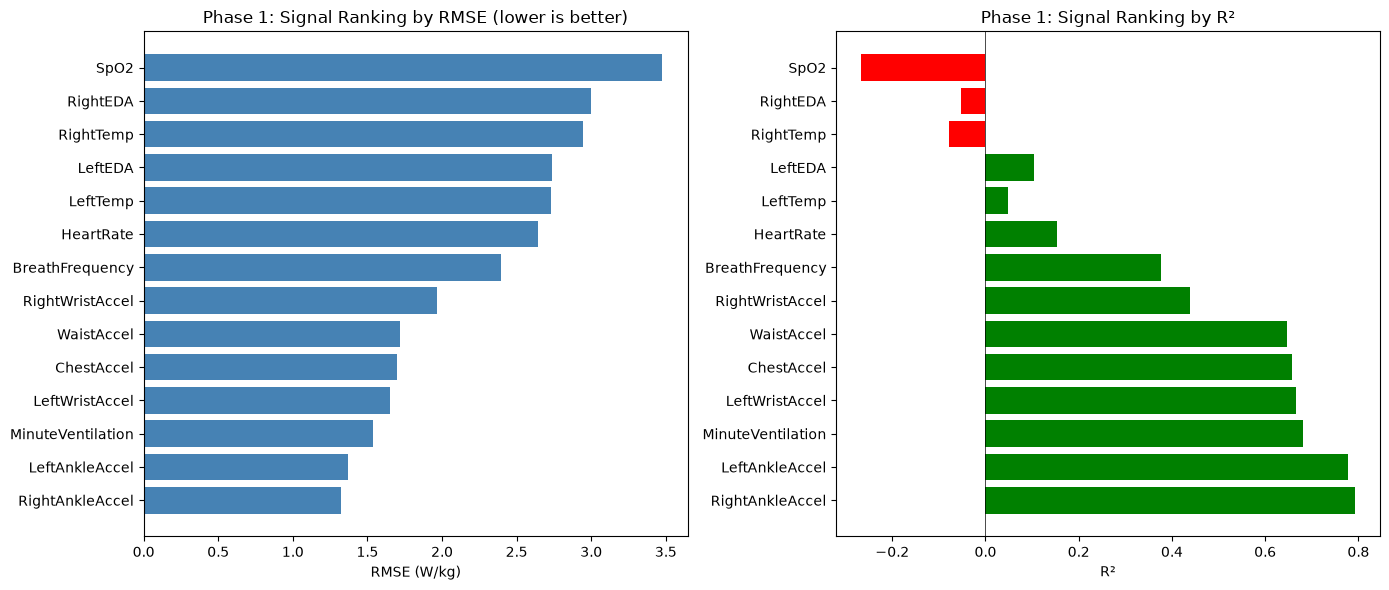

Saved.


In [25]:
plot_signal_ranking(phase1_results)

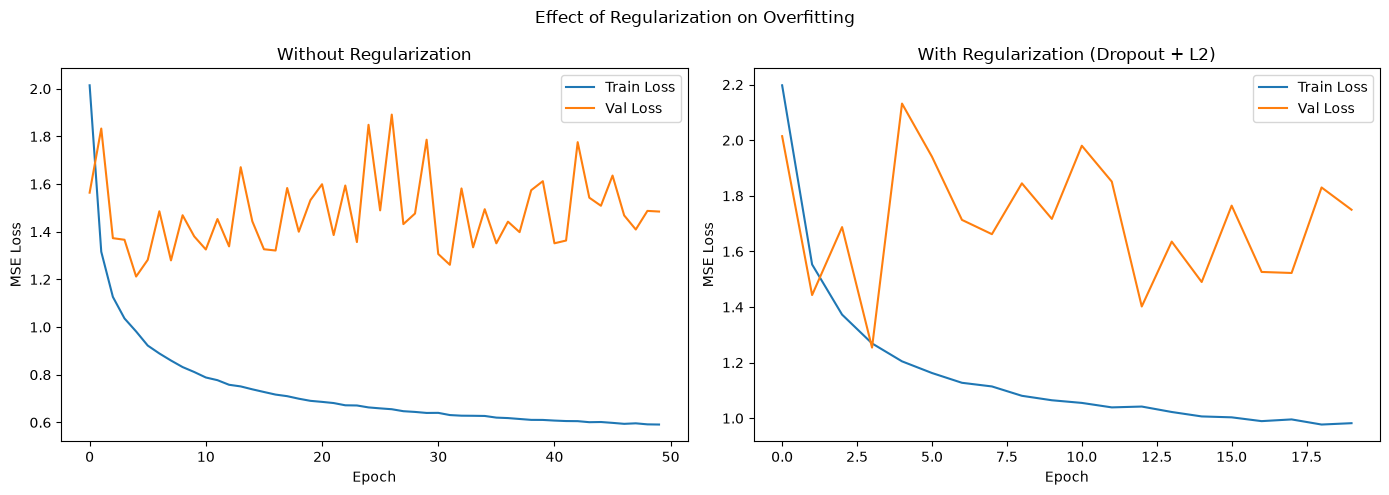

In [26]:
# Split Subject01-08 for train, Subject09 for val, Subject10 for test
train_dataset = EEDataset(['Subject01','Subject02','Subject03','Subject04',
                           'Subject05','Subject06','Subject07','Subject08'], 
                           labels, 'APDM_Accel', [29,30,31])
val_dataset = EEDataset(['Subject09'], labels, 'APDM_Accel', [29,30,31])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

model_reg = Net()
optimizer = optim.Adam(model_reg.parameters(), lr=0.001, weight_decay=1e-4)
train_losses_reg, val_losses_reg = [], []

for epoch in range(20):
    model_reg.train()
    train_loss = 0
    for windows, targets in train_loader:
        optimizer.zero_grad()
        predictions = model_reg(windows)
        loss = criterion(predictions.squeeze(1), targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    model_reg.eval()
    val_loss = 0
    with torch.no_grad():
        for windows, targets in val_loader:
            predictions = model_reg(windows)
            loss = criterion(predictions.squeeze(1), targets)
            val_loss += loss.item()
    
    train_losses_reg.append(train_loss / len(train_loader))
    val_losses_reg.append(val_loss / len(val_loader))

class NetNoReg(nn.Module):
    def __init__(self):
        super(NetNoReg, self).__init__()
        self.conv1 = nn.Conv1d(1, 32, 5)
        self.conv2 = nn.Conv1d(32, 64, 5)
        self.conv3 = nn.Conv1d(64, 64, 5)
        self.adaptivepool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        x = F.relu(F.max_pool1d(self.conv1(x), 2))
        x = F.relu(F.max_pool1d(self.conv2(x), 2))
        x = F.relu(F.max_pool1d(self.conv3(x), 2))
        x = self.adaptivepool(x).squeeze(-1)
        return self.fc(x)

model_noreg = NetNoReg()
optimizer_noreg = optim.Adam(model_noreg.parameters(), lr=0.001)
train_losses_noreg, val_losses_noreg = [], []

for epoch in range(50):
    model_noreg.train()
    train_loss = 0
    for windows, targets in train_loader:
        optimizer_noreg.zero_grad()
        predictions = model_noreg(windows)
        loss = criterion(predictions.squeeze(1), targets)
        loss.backward()
        optimizer_noreg.step()
        train_loss += loss.item()
    
    model_noreg.eval()
    val_loss = 0
    with torch.no_grad():
        for windows, targets in val_loader:
            predictions = model_noreg(windows)
            loss = criterion(predictions.squeeze(1), targets)
            val_loss += loss.item()
    
    train_losses_noreg.append(train_loss / len(train_loader))
    val_losses_noreg.append(val_loss / len(val_loader))

# Plot both
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses_noreg, label='Train Loss')
ax1.plot(val_losses_noreg, label='Val Loss')
ax1.set_title('Without Regularization')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.legend()

ax2.plot(train_losses_reg, label='Train Loss')
ax2.plot(val_losses_reg, label='Val Loss')
ax2.set_title('With Regularization (Dropout + L2)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MSE Loss')
ax2.legend()

plt.suptitle('Effect of Regularization on Overfitting')
plt.tight_layout()
plt.savefig('/Users/alexanderwuckert/Desktop/task2/learning_curves.png', dpi=150)
plt.show()

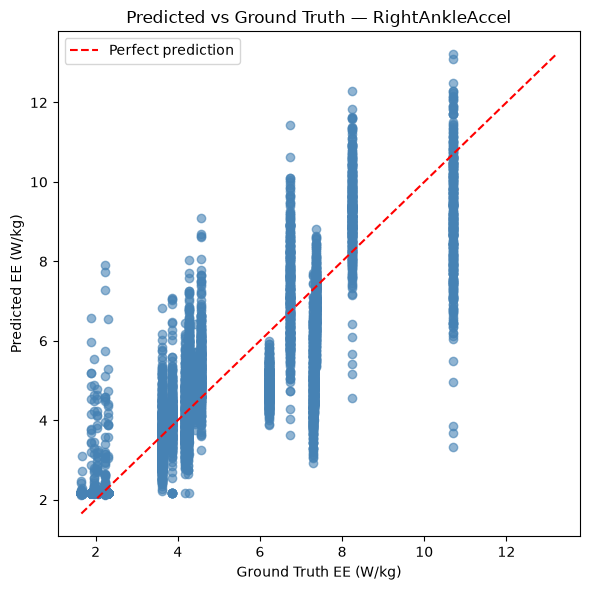

In [27]:
# Scatter plot for best signal - RightAnkleAccel
test_dataset = EEDataset(['Subject10'], labels, 'APDM_Accel', [29,30,31])
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

model_best = Net()
optimizer_best = optim.Adam(model_best.parameters(), lr=0.001, weight_decay=1e-4)
train_dataset_best = EEDataset(['Subject01','Subject02','Subject03','Subject04',
                                'Subject05','Subject06','Subject07','Subject08','Subject09'],
                                labels, 'APDM_Accel', [29,30,31])
train_loader_best = DataLoader(train_dataset_best, batch_size=8, shuffle=True)

for epoch in range(20):
    model_best.train()
    for windows, targets in train_loader_best:
        optimizer_best.zero_grad()
        predictions = model_best(windows)
        loss = criterion(predictions.squeeze(1), targets)
        loss.backward()
        optimizer_best.step()

model_best.eval()
preds, actuals = [], []
with torch.no_grad():
    for windows, targets in test_loader:
        predictions = model_best(windows)
        preds.extend(predictions.squeeze(1).numpy())
        actuals.extend(targets.numpy())

preds = np.array(preds)
actuals = np.array(actuals)

plt.figure(figsize=(6,6))
plt.scatter(actuals, preds, alpha=0.6, color='steelblue')
min_val = min(actuals.min(), preds.min())
max_val = max(actuals.max(), preds.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
plt.xlabel('Ground Truth EE (W/kg)')
plt.ylabel('Predicted EE (W/kg)')
plt.title('Predicted vs Ground Truth — RightAnkleAccel')
plt.legend()
plt.tight_layout()
plt.savefig('/Users/alexanderwuckert/Desktop/task2/scatter_best.png', dpi=150)
plt.show()

In [28]:
G1 = {
    'WaistAccel':     ('APDM_Accel', [2,3,4]),
    'ChestAccel':     ('APDM_Accel', [11,12,13]),
    'LeftAnkleAccel': ('APDM_Accel', [20,21,22]),
    'RightAnkleAccel':('APDM_Accel', [29,30,31]),
    'LeftWristAccel': ('Empatica_Accel', [2,3,4]),
    'RightWristAccel':('Empatica_Accel', [5,6,7]),
    'LeftEMG':        ('EMG', list(range(2,10))),
    'RightEMG':       ('EMG', list(range(10,18))),
}

G2 = {
    'LeftEDA':           ('Empatica_Physio', 2),
    'RightEDA':          ('Empatica_Physio', 4),
    'LeftTemp':          ('Empatica_Physio', 3),
    'RightTemp':         ('Empatica_Physio', 5),
    'BreathFrequency':   ('Metabolics_System', 5),
    'MinuteVentilation': ('Metabolics_System', 6),
    'HeartRate':         ('Metabolics_System', 8),
    'SpO2':              ('Metabolics_System', 7),
}

G3 = {
    'WaistAccel':        ('APDM_Accel', [2,3,4]),
    'BreathFrequency':   ('Metabolics_System', 5),
    'MinuteVentilation': ('Metabolics_System', 6),
    'HeartRate':         ('Metabolics_System', 8),
}

G4 = {
    'BreathFrequency':   ('Metabolics_System', 5),
    'MinuteVentilation': ('Metabolics_System', 6),
    'HeartRate':         ('Metabolics_System', 8),
    'SpO2':              ('Metabolics_System', 7),
}

G5 = {
    'WaistAccel':        ('APDM_Accel', [2,3,4]),
    'ChestAccel':        ('APDM_Accel', [11,12,13]),
    'LeftAnkleAccel':    ('APDM_Accel', [20,21,22]),
    'RightAnkleAccel':   ('APDM_Accel', [29,30,31]),
    'LeftWristAccel':    ('Empatica_Accel', [2,3,4]),
    'RightWristAccel':   ('Empatica_Accel', [5,6,7]),
}

G6 = {**G1, **G2}  # all 16 signals

In [29]:
import torch.nn as nn

In [30]:

class EarlyFusionNet(nn.Module):
    def __init__(self, n_signals):
        super(EarlyFusionNet, self).__init__()
        self.conv1 = nn.Conv1d(n_signals, 32, 5)
        self.conv2 = nn.Conv1d(32, 64, 5)
        self.conv3 = nn.Conv1d(64, 64, 5)
        self.conv1_bnorm = nn.BatchNorm1d(32)
        self.conv2_bnorm = nn.BatchNorm1d(64)
        self.conv3_bnorm = nn.BatchNorm1d(64)
        self.dropout = nn.Dropout(0.3)
        self.adaptivepool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        x = self.conv1_bnorm(F.relu(F.max_pool1d(self.conv1(x), 2)))
        x = self.conv2_bnorm(F.relu(F.max_pool1d(self.conv2(x), 2)))
        x = self.conv3_bnorm(F.relu(F.max_pool1d(self.conv3(x), 2)))
        x = self.adaptivepool(x).squeeze(-1)
        x = self.dropout(x)
        return self.fc(x)

In [31]:
class IntermediateFusionNet(nn.Module):
    def __init__(self, n_signals):
        super(IntermediateFusionNet, self).__init__()
        self.encoders = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(1, 32, 5),
                nn.BatchNorm1d(32),
                nn.ReLU(),
                nn.MaxPool1d(2),
                nn.Conv1d(32, 64, 5),
                nn.BatchNorm1d(64),
                nn.ReLU(),
                nn.AdaptiveAvgPool1d(1)
            ) for _ in range(n_signals)
        ])
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(64 * n_signals, 1)

    def forward(self, x):
        # x shape: (batch, n_signals, time)
        features = [enc(x[:, i:i+1, :]).squeeze(-1) for i, enc in enumerate(self.encoders)]
        combined = torch.cat(features, dim=1)
        combined = self.dropout(combined)
        return self.fc(combined)

In [32]:
class LateFusionNet(nn.Module):
    def __init__(self, n_signals):
        super(LateFusionNet, self).__init__()
        self.branches = nn.ModuleList([Net() for _ in range(n_signals)])
        self.combine = nn.Linear(n_signals, 1)

    def forward(self, x):
        # x shape: (batch, n_signals, time)
        preds = [branch(x[:, i:i+1, :]) for i, branch in enumerate(self.branches)]
        preds = torch.cat(preds, dim=1)
        return self.combine(preds)

In [33]:
class MultiSignalDataset(Dataset):
    def __init__(self, subjects, labels, signal_list, window_size=128):
        self.windows = []
        self.targets = []
        
        for subject in subjects:
            for activity in activities:
                try:
                    signals_data = {}
                    min_len = None
                    activity_codes = None
                    for sig_name, (group, row) in signal_list.items():
                        data = get_data(subject, activity, group)
                        if activity_codes is None:
                            activity_codes = data[1]
                        if isinstance(row, list):
                            sig = np.sqrt(np.sum(data[row]**2, axis=0))
                        else:
                            sig = data[row]
                        signals_data[sig_name] = sig
                    
                    # resample all signals to same length
                    lengths = [len(s) for s in signals_data.values()]
                    min_len = min(lengths)
                    
                    for sig_name in signals_data:
                        signals_data[sig_name] = signals_data[sig_name][:min_len]
                    activity_codes = activity_codes[:min_len]
                    
                    for code in np.unique(activity_codes):
                        label = labels.get((subject, activity, code), None)
                        if label is None:
                            continue
                        mask = activity_codes == code
                        
                        signal_stack = np.stack([signals_data[s][mask] for s in signals_data])
                        
                        for i in range(0, signal_stack.shape[1] - window_size, window_size):
                            window = signal_stack[:, i:i+window_size]
                            self.windows.append(torch.tensor(window, dtype=torch.float32))
                            self.targets.append(torch.tensor(label, dtype=torch.float32))
                except:
                    continue

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        return self.windows[idx], self.targets[idx]

In [34]:
G1 = {
    'WaistAccel':     ('APDM_Accel', [2,3,4]),
    'ChestAccel':     ('APDM_Accel', [11,12,13]),
    'LeftAnkleAccel': ('APDM_Accel', [20,21,22]),
    'RightAnkleAccel':('APDM_Accel', [29,30,31]),
    'LeftWristAccel': ('Empatica_Accel', [2,3,4]),
    'RightWristAccel':('Empatica_Accel', [5,6,7]),

}

G2 = {
    'LeftEDA':           ('Empatica_Physio', 2),
    'RightEDA':          ('Empatica_Physio', 4),
    'LeftTemp':          ('Empatica_Physio', 3),
    'RightTemp':         ('Empatica_Physio', 5),
    'BreathFrequency':   ('Metabolics_System', 5),
    'MinuteVentilation': ('Metabolics_System', 6),
    'HeartRate':         ('Metabolics_System', 8),
    'SpO2':              ('Metabolics_System', 7),
}

G3 = {
    'WaistAccel':        ('APDM_Accel', [2,3,4]),
    'BreathFrequency':   ('Metabolics_System', 5),
    'MinuteVentilation': ('Metabolics_System', 6),
    'HeartRate':         ('Metabolics_System', 8),
}

G4 = {
    'BreathFrequency':   ('Metabolics_System', 5),
    'MinuteVentilation': ('Metabolics_System', 6),
    'HeartRate':         ('Metabolics_System', 8),
    'SpO2':              ('Metabolics_System', 7),
}

G5 = {
    'WaistAccel':        ('APDM_Accel', [2,3,4]),
    'ChestAccel':        ('APDM_Accel', [11,12,13]),
    'LeftAnkleAccel':    ('APDM_Accel', [20,21,22]),
    'RightAnkleAccel':   ('APDM_Accel', [29,30,31]),
    'LeftWristAccel':    ('Empatica_Accel', [2,3,4]),
    'RightWristAccel':   ('Empatica_Accel', [5,6,7]),
}

G6 = {**G1, **G2}  # all 16 signals

In [ ]:
def run_fusion_loso(signal_group, fusion_type='early'):
    all_subjects = ['Subject01', 'Subject02', 'Subject03', 'Subject04', 'Subject05',
                    'Subject06', 'Subject07', 'Subject08', 'Subject09', 'Subject10']
    n_signals = len(signal_group)
    fold_results = []
    
    for test_subject in all_subjects:
        train_subjects = [s for s in all_subjects if s != test_subject]
        
        train_dataset = MultiSignalDataset(train_subjects, labels, signal_group)
        test_dataset = MultiSignalDataset([test_subject], labels, signal_group)
        
        if len(test_dataset) < 5:
            continue
        
        train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)
        
        if fusion_type == 'early':
            model = EarlyFusionNet(n_signals)
        elif fusion_type == 'late':
            model = LateFusionNet(n_signals)
        else:
            model = IntermediateFusionNet(n_signals)
        
        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
        
        for epoch in range(20):
            model.train()
            for windows, targets in train_loader:
                optimizer.zero_grad()
                predictions = model(windows)
                loss = criterion(predictions.squeeze(1), targets)
                loss.backward()
                optimizer.step()
        
        model.eval()
        preds, actuals = [], []
        with torch.no_grad():
            for windows, targets in test_loader:
                predictions = model(windows)
                preds.extend(predictions.squeeze(1).numpy())
                actuals.extend(targets.numpy())
        
      
        preds = np.array(preds)
        actuals = np.array(actuals)
        
        valid = ~(np.isnan(preds) | np.isnan(actuals))
        preds = preds[valid]
        actuals = actuals[valid]
        
        if len(preds) < 2:
            continue
        
        rmse = np.sqrt(np.mean((preds - actuals)**2))
        mae = np.mean(np.abs(preds - actuals))
        r2 = r2_score(actuals, preds)
        fold_results.append({'RMSE': rmse, 'MAE': mae, 'R2': r2})

        # --- MEMORY CLEANUP ---
        # Same reasoning as run_loso: MultiSignalDataset objects hold stacked
        # multi-channel tensors (larger than single-signal EEDataset), so this
        # matters even more here. Delete + collect after every fold.
        del train_dataset, test_dataset, train_loader, test_loader, model, optimizer
        gc.collect()
    
    save_cache()

    if fold_results:
        return (np.mean([r['RMSE'] for r in fold_results]),
                np.mean([r['MAE'] for r in fold_results]),
                np.mean([r['R2'] for r in fold_results]))
    return None, None, None

In [36]:

import torch.optim as optim
from sklearn.metrics import r2_score
criterion = nn.MSELoss()


In [37]:
try:
    with open('/Users/alexanderwuckert/Desktop/task2/phase2_results.pkl', 'rb') as f:
        phase2_results = pickle.load(f)
    print(f"Loaded existing: {list(phase2_results.keys())}")
except:
    phase2_results = {}

groups = {'G1': G1, 'G2': G2, 'G3': G3, 'G4': G4, 'G5': G5, 'G6': G6}

for group_name, signal_group in groups.items():
    if group_name not in phase2_results:
        phase2_results[group_name] = {}
    for fusion_type in ['early', 'intermediate', 'late']:
        if fusion_type in phase2_results.get(group_name, {}):
            print(f"Skipping {group_name} {fusion_type} — already done")
            continue
        print(f"Running {group_name} {fusion_type}...")
        rmse, mae, r2 = run_fusion_loso(signal_group, fusion_type)
        if rmse is not None:
            phase2_results[group_name][fusion_type] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
            print(f"  {group_name} {fusion_type}: RMSE={rmse:.3f}, MAE={mae:.3f}, R²={r2:.3f}")
        with open('/Users/alexanderwuckert/Desktop/task2/phase2_results.pkl', 'wb') as f:
            pickle.dump(phase2_results, f)

Running G1 early...
  G1 early: RMSE=0.742, MAE=0.525, R²=0.749
Running G1 intermediate...
  G1 intermediate: RMSE=1.005, MAE=0.872, R²=0.498
Running G1 late...
  G1 late: RMSE=0.767, MAE=0.555, R²=0.703
Running G2 early...
  G2 early: RMSE=0.193, MAE=0.145, R²=-1.736
Running G2 intermediate...
  G2 intermediate: RMSE=0.177, MAE=0.141, R²=-1.312
Running G2 late...
  G2 late: RMSE=0.144, MAE=0.122, R²=-0.524
Running G3 early...
  G3 early: RMSE=0.465, MAE=0.385, R²=-2.259
Running G3 intermediate...
  G3 intermediate: RMSE=1.626, MAE=1.571, R²=-125.136
Running G3 late...
  G3 late: RMSE=0.636, MAE=0.551, R²=-5.787
Running G4 early...
  G4 early: RMSE=3.302, MAE=3.197, R²=-0.348
Running G4 intermediate...
  G4 intermediate: RMSE=3.172, MAE=2.901, R²=-0.427
Running G4 late...
  G4 late: RMSE=1.414, MAE=1.219, R²=0.758
Running G5 early...
  G5 early: RMSE=0.758, MAE=0.523, R²=0.721
Running G5 intermediate...
  G5 intermediate: RMSE=1.641, MAE=1.473, R²=-0.639
Running G5 late...
  G5 late: R

In [38]:
print(len(G1), len(G2), len(G3), len(G4), len(G5), len(G6))
print(EarlyFusionNet, LateFusionNet, IntermediateFusionNet)
print(MultiSignalDataset)
print(len(labels))

6 8 4 4 6 14
<class '__main__.EarlyFusionNet'> <class '__main__.LateFusionNet'> <class '__main__.IntermediateFusionNet'>
<class '__main__.MultiSignalDataset'>
253


In [39]:
print(sorted(phase1_results.items(), key=lambda x: x[1]['RMSE']))

[('RightAnkleAccel', {'RMSE': np.float32(1.3228527), 'MAE': np.float32(0.93355024), 'R2': np.float64(0.793291699886322)}), ('LeftAnkleAccel', {'RMSE': np.float32(1.3665501), 'MAE': np.float32(0.9781324), 'R2': np.float64(0.7781794488430023)}), ('MinuteVentilation', {'RMSE': np.float32(1.5360376), 'MAE': np.float32(1.2515153), 'R2': np.float64(0.680249445968204)}), ('LeftWristAccel', {'RMSE': np.float32(1.6536433), 'MAE': np.float32(1.2059288), 'R2': np.float64(0.6652720808982849)}), ('ChestAccel', {'RMSE': np.float32(1.6980426), 'MAE': np.float32(1.1848327), 'R2': np.float64(0.6581008076667786)}), ('WaistAccel', {'RMSE': np.float32(1.7208226), 'MAE': np.float32(1.2130051), 'R2': np.float64(0.6466219842433929)}), ('RightWristAccel', {'RMSE': np.float32(1.9646336), 'MAE': np.float32(1.5262988), 'R2': np.float64(0.4396117031574249)}), ('BreathFrequency', {'RMSE': np.float32(2.3934371), 'MAE': np.float32(1.9923823), 'R2': np.float64(0.37607812219195896)}), ('HeartRate', {'RMSE': np.float32